# 🚀 Startup Funding Success Probability — India 2026
**AI & ML Internship Program | Task 4**

---
**Domain:** Statistics + Probability + Data Analytics + Startup Intelligence  
**Dataset:** Recently Funded Startups In India 2026  
**Goal:** Identify statistical indicators associated with startup funding success

---

## 📦 Phase 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# ✅ BASE PATH — only change this if you move the project
BASE = r'C:\Users\ADMIN\OneDrive\Desktop\Startup Funding Success Probability'
DATA_PATH = os.path.join(BASE, 'data', 'Recently Funded Startups In India 2026.csv')
IMG_PATH  = os.path.join(BASE, 'images')
os.makedirs(IMG_PATH, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_PATH)

print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Shape        : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns      : {df.columns.tolist()}')
print(f'\nData Types:')
print(df.dtypes)
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicates   : {df.duplicated().sum()}')
print('\nFirst 5 rows:')
df.head()

DATASET OVERVIEW
Shape        : 100 rows × 7 columns
Columns      : ['Name', 'Website', 'Industry', 'Country', 'Funding Amount (USD)', 'Funding Type', 'Last Funding Date']

Data Types:
Name                    str
Website                 str
Industry                str
Country                 str
Funding Amount (USD)    str
Funding Type            str
Last Funding Date       str
dtype: object

Missing Values:
Name                     0
Website                  0
Industry                 0
Country                  0
Funding Amount (USD)    13
Funding Type             0
Last Funding Date        0
dtype: int64

Duplicates   : 0

First 5 rows:


,Name,Website,Industry,Country,Funding Amount (USD),Funding Type,Last Funding Date
0,EarthSync,earthsync.io,"Energy, Analytics, Artificial Intelligence, B2...",India,"$1,000,000",Pre-Seed,February 2026
1,4baseCare,4basecare.com,"Healthcare, Artificial Intelligence, B2B Softw...",India,"$9,803,025",Series B,February 2026
2,Cava Athleisure,cavaathleisure.com,"Fashion, Wellness, Consumer Goods, E-commerce,...",India,"$4,353,085",Series A,February 2026
3,JuniorGo,juniorgo.in,"Education, Finance, Personal Development",India,NaN,Pre-Seed,February 2026
4,Entellus Industries,entellusind.com,"Materials, Automotive, Electronics, EV, Manufa...",India,"$5,446,125",Seed,February 2026


In [6]:
import pandas as pd
import numpy as np
import os

# ===== FILE PATH =====
DATA_PATH =r"C:\Users\ADMIN\OneDrive\Desktop\Startup Funding Success Probability\data\Recently Funded Startups In India 2026.csv"

# ===== LOAD DATA =====
df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print(df.head())

# ===== CLEAN DATA =====

# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Convert Funding Amount to numeric
df['Funding Amount (USD)'] = (
    df['Funding Amount (USD)']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Funding Amount (USD)'] = pd.to_numeric(
    df['Funding Amount (USD)'],
    errors='coerce'
)

# 3. Funded flag
df['Funded'] = df['Funding Amount (USD)'].notna().astype(int)

# 4. Extract primary industry
df['Primary Industry'] = (
    df['Industry']
    .astype(str)
    .str.split(',')
    .str[0]
    .str.strip()
)

# 5. Parse date safely
df['Last Funding Date'] = pd.to_datetime(
    df['Last Funding Date'],
    errors='coerce'
)

df['Funding Month'] = df['Last Funding Date'].dt.month_name()

# ===== SUMMARY =====

total = len(df)
funded_n = int(df['Funded'].sum())
unfunded_n = total - funded_n

print("=" * 50)
print("DATA CLEANING COMPLETE")
print("=" * 50)

print(f"Total Startups            : {total}")
print(f"Funded                    : {funded_n}")
print(f"Funding Not Disclosed     : {unfunded_n}")

print("\nFunding Types:")
print(df['Funding Type'].value_counts())

print("\nTop Primary Industries:")
print(df['Primary Industry'].value_counts().head(10))

Dataset Loaded Successfully
                  Name             Website  \
0            EarthSync        earthsync.io   
1            4baseCare       4basecare.com   
2      Cava Athleisure  cavaathleisure.com   
3             JuniorGo         juniorgo.in   
4  Entellus Industries     entellusind.com   

                                            Industry Country  \
0  Energy, Analytics, Artificial Intelligence, B2...   India   
1  Healthcare, Artificial Intelligence, B2B Softw...   India   
2  Fashion, Wellness, Consumer Goods, E-commerce,...   India   
3           Education, Finance, Personal Development   India   
4  Materials, Automotive, Electronics, EV, Manufa...   India   

  Funding Amount (USD) Funding Type Last Funding Date  
0           $1,000,000     Pre-Seed     February 2026  
1           $9,803,025     Series B     February 2026  
2           $4,353,085     Series A     February 2026  
3                  NaN     Pre-Seed     February 2026  
4           $5,446,125        

## 📊 Phase 2: Descriptive Statistical Analysis

In [7]:
# ===== DESCRIPTIVE STATISTICS =====

# Check required columns
required_cols = [
    'Funding Amount (USD)',
    'Funding Type',
    'Funded'
]

for col in required_cols:
    if col not in df.columns:
        print(f"Column not found: {col}")

# Select funded startups only
funded_df = df[df['Funded'] == 1].copy()

# Funding amount series
amt = funded_df['Funding Amount (USD)']

print('=' * 55)
print('DESCRIPTIVE STATISTICS — FUNDING AMOUNT (USD)')
print('=' * 55)

print(f'Count        : {amt.count()}')
print(f'Mean         : ${amt.mean():,.0f}')
print(f'Median       : ${amt.median():,.0f}')
print(f'Std Dev      : ${amt.std():,.0f}')
print(f'Min          : ${amt.min():,.0f}')
print(f'Max          : ${amt.max():,.0f}')
print(f'10th Pctile  : ${amt.quantile(0.10):,.0f}')
print(f'25th Pctile  : ${amt.quantile(0.25):,.0f}')
print(f'75th Pctile  : ${amt.quantile(0.75):,.0f}')
print(f'90th Pctile  : ${amt.quantile(0.90):,.0f}')

print('\nAverage Funding by Funding Type (USD):')

funding_stats = (
    df.groupby('Funding Type')['Funding Amount (USD)']
      .agg(['mean', 'median', 'count'])
      .rename(columns={
          'mean': 'Mean',
          'median': 'Median',
          'count': 'Count'
      })
      .sort_values('Mean', ascending=False)
)

print(funding_stats)

DESCRIPTIVE STATISTICS — FUNDING AMOUNT (USD)
Count        : 87
Mean         : $15,126,296
Median       : $3,000,000
Std Dev      : $40,492,646
Min          : $82,941
Max          : $304,527,929
10th Pctile  : $210,210
25th Pctile  : $1,000,000
75th Pctile  : $9,901,512
90th Pctile  : $26,160,000

Average Funding by Funding Type (USD):
                                  Mean       Median  Count
Funding Type                                              
Private Equity            1.410183e+08  115738738.0      5
Series D                  4.719487e+07   51000000.0      3
Series E                  2.191832e+07   21918324.0      1
Series C                  2.153608e+07   26414958.5      4
Series B                  1.195037e+07    9803025.0      5
Series A                  1.128399e+07    8823156.0     15
Venture - Series Unknown  8.664248e+06    2600000.0      5
Seed                      2.125245e+06    1985210.0     39
Convertible Note          1.090000e+06    1090000.0      1
Pre-Seed     

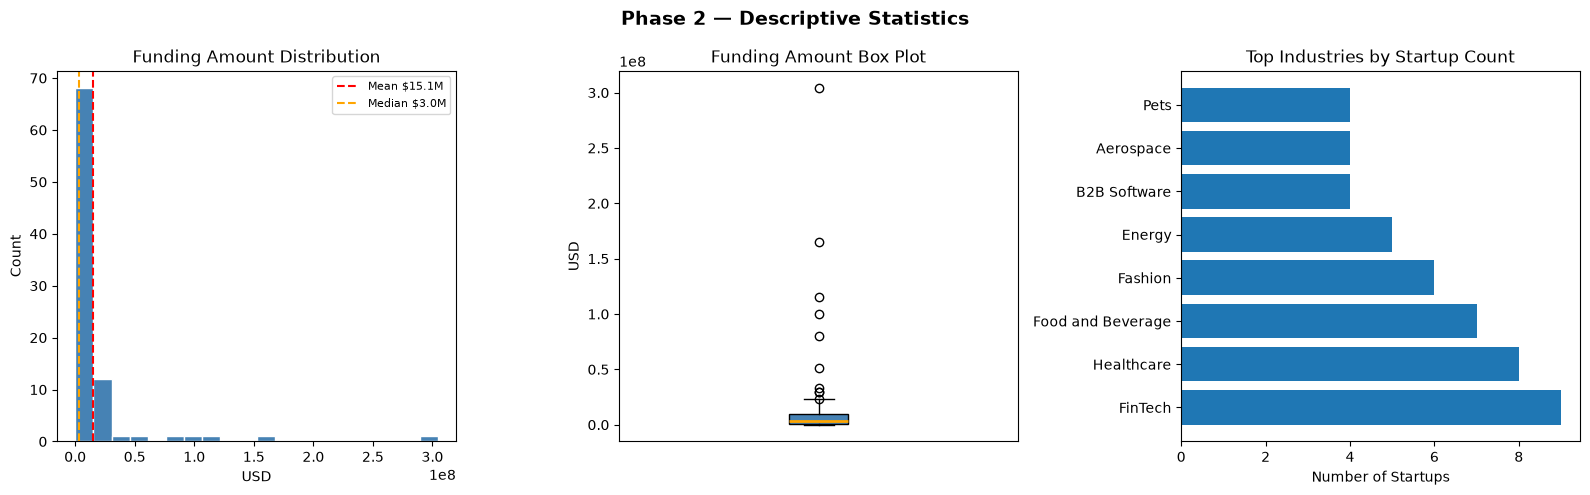

✅ Saved: phase2_descriptive_stats.png


In [8]:
# Create funded dataset
funded_df = df[df['Funded'] == 1].copy()

# Create amt variable
amt = funded_df['Funding Amount (USD)']

# Create images folder if it doesn't exist
import os
os.makedirs(IMG_PATH, exist_ok=True)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 2 — Descriptive Statistics', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(amt.dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(amt.mean(), color='red', linestyle='--',
                label=f'Mean ${amt.mean()/1e6:.1f}M')
axes[0].axvline(amt.median(), color='orange', linestyle='--',
                label=f'Median ${amt.median()/1e6:.1f}M')
axes[0].set_title('Funding Amount Distribution')
axes[0].set_xlabel('USD')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Box Plot
axes[1].boxplot(
    amt.dropna(),
    patch_artist=True,
    boxprops=dict(facecolor='steelblue'),
    medianprops=dict(color='orange', linewidth=2)
)
axes[1].set_title('Funding Amount Box Plot')
axes[1].set_ylabel('USD')
axes[1].set_xticks([])

# Top Industries
top = df['Primary Industry'].value_counts().head(8)

axes[2].barh(top.index, top.values)
axes[2].set_title('Top Industries by Startup Count')
axes[2].set_xlabel('Number of Startups')

plt.tight_layout()

plt.savefig(
    os.path.join(IMG_PATH, 'phase2_descriptive_stats.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved: phase2_descriptive_stats.png")

## 🎲 Phase 3: Probability Investigation

In [9]:
print('=' * 55)
print('PROBABILITY ANALYSIS')
print('=' * 55)

def prob_funded(mask, label):
    subset = df[mask]

    if len(subset) == 0:
        print(f'P({label}) = No Data')
        return

    p = subset['Funded'].mean()

    print(
        f'P({label}) = {p:.2%} '
        f'[{subset["Funded"].sum()}/{len(subset)}]'
    )

print('\n--- By Industry ---')

industries = [
    'Artificial Intelligence',
    'FinTech',
    'Healthcare',
    'Energy',
    'E-commerce',
    'Education'
]

for ind in industries:
    prob_funded(
        df['Industry'].astype(str).str.contains(ind, case=False, na=False),
        f'{ind} startup funded'
    )

print('\n--- By Funding Stage ---')

for ft in [
    'Pre-Seed',
    'Seed',
    'Series A',
    'Series B',
    'Series C',
    'Private Equity'
]:
    prob_funded(
        df['Funding Type'] == ft,
        f'{ft} disclosed funding'
    )

print('\n--- High Value Probability ---')

prob_funded(
    (df['Funding Type'] == 'Series A') &
    (df['Funding Amount (USD)'] > 5000000),
    'Series A > $5M'
)

prob_funded(
    df['Funding Amount (USD)'] > 10000000,
    'Funding > $10M'
)

print('\n--- By Month ---')

month_stats = (
    df.groupby('Funding Month')['Funded']
      .agg(['mean', 'count'])
      .rename(
          columns={
              'mean': 'P(Funded)',
              'count': 'Total'
          }
      )
)

print(month_stats)

PROBABILITY ANALYSIS

--- By Industry ---
P(Artificial Intelligence startup funded) = 100.00% [14/14]
P(FinTech startup funded) = 77.78% [7/9]
P(Healthcare startup funded) = 92.31% [12/13]
P(Energy startup funded) = 100.00% [7/7]
P(E-commerce startup funded) = 95.83% [23/24]
P(Education startup funded) = 50.00% [2/4]

--- By Funding Stage ---
P(Pre-Seed disclosed funding) = 75.00% [9/12]
P(Seed disclosed funding) = 88.64% [39/44]
P(Series A disclosed funding) = 93.75% [15/16]
P(Series B disclosed funding) = 83.33% [5/6]
P(Series C disclosed funding) = 100.00% [4/4]
P(Private Equity disclosed funding) = 71.43% [5/7]

--- High Value Probability ---
P(Series A > $5M) = 100.00% [10/10]
P(Funding > $10M) = 100.00% [20/20]

--- By Month ---
               P(Funded)  Total
Funding Month                  
February        0.826087     69
January         0.967742     31


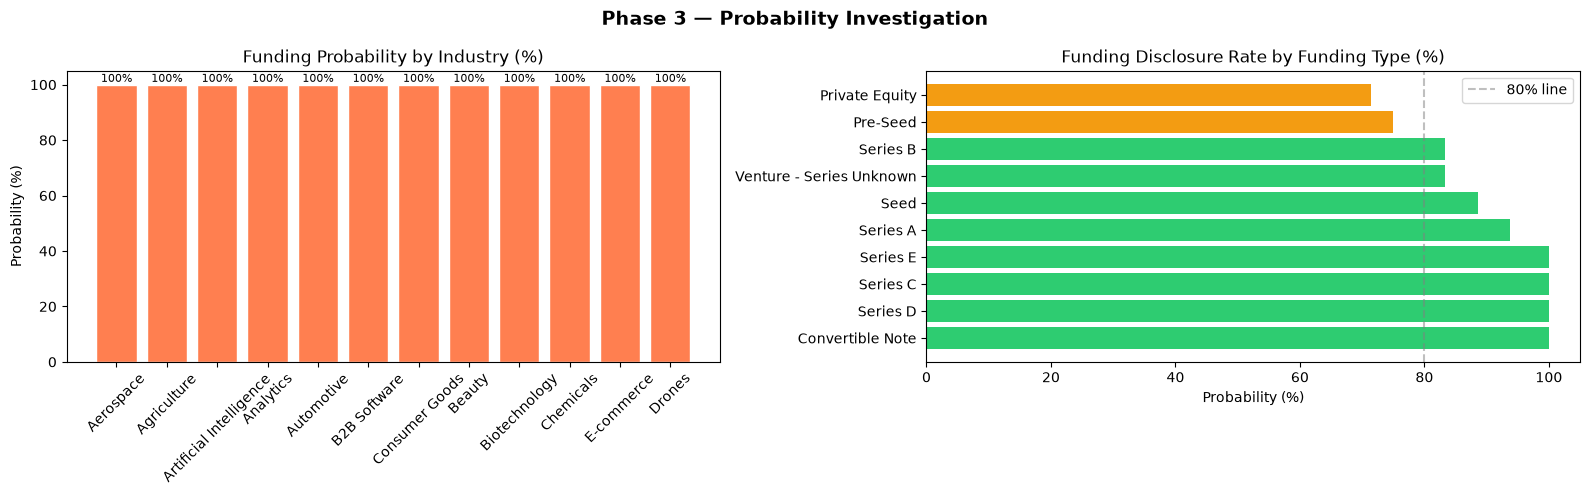

✅ Saved: phase3_probability.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =========================
# LOAD DATASET
# =========================

DATA_PATH = r"C:\Users\ADMIN\OneDrive\Desktop\Startup Funding Success Probability\data\Recently Funded Startups In India 2026.csv"

df = pd.read_csv(DATA_PATH)

# =========================
# DATA CLEANING
# =========================

df['Funding Amount (USD)'] = (
    df['Funding Amount (USD)']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Funding Amount (USD)'] = pd.to_numeric(
    df['Funding Amount (USD)'],
    errors='coerce'
)

df['Funded'] = df['Funding Amount (USD)'].notna().astype(int)

df['Primary Industry'] = (
    df['Industry']
    .astype(str)
    .str.split(',')
    .str[0]
    .str.strip()
)

# =========================
# CREATE IMAGE FOLDER
# =========================

IMG_PATH = "images"
os.makedirs(IMG_PATH, exist_ok=True)

# =========================
# PHASE 3 GRAPH
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'Phase 3 — Probability Investigation',
    fontsize=14,
    fontweight='bold'
)

# Probability by Industry
ind_prob = (
    df.groupby('Primary Industry')['Funded']
      .mean()
      .sort_values(ascending=False)
      .head(12)
)

bars = axes[0].bar(
    ind_prob.index,
    ind_prob.values * 100,
    color='coral',
    edgecolor='white'
)

axes[0].set_title('Funding Probability by Industry (%)')
axes[0].set_ylabel('Probability (%)')
axes[0].tick_params(axis='x', rotation=45)

for bar, val in zip(bars, ind_prob.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val*100:.0f}%',
        ha='center',
        fontsize=8
    )

# Probability by Funding Type
ft_prob = (
    df.groupby('Funding Type')['Funded']
      .mean()
      .sort_values(ascending=False)
)

colors = [
    '#2ecc71' if v > 0.8
    else '#f39c12' if v > 0.5
    else '#e74c3c'
    for v in ft_prob.values
]

axes[1].barh(
    ft_prob.index,
    ft_prob.values * 100,
    color=colors
)

axes[1].set_title(
    'Funding Disclosure Rate by Funding Type (%)'
)

axes[1].set_xlabel('Probability (%)')

axes[1].axvline(
    80,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label='80% line'
)

axes[1].legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMG_PATH,
        'phase3_probability.png'
    ),
    dpi=150
)

plt.show()

print("✅ Saved: phase3_probability.png")

## 🔗 Phase 4: Relationship Analysis

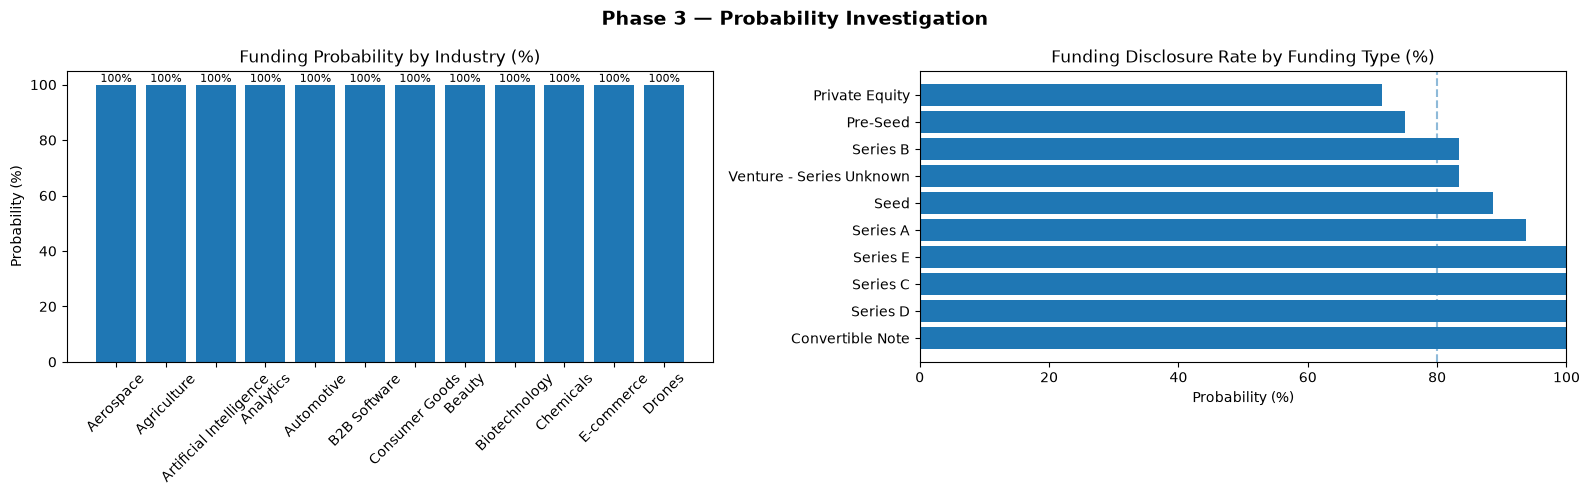

✅ Saved: phase3_probability.png


In [10]:
# Create image folder
os.makedirs(IMG_PATH, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 3 — Probability Investigation',
             fontsize=14,
             fontweight='bold')

# Probability by Industry
ind_prob = (
    df.groupby('Primary Industry')['Funded']
      .mean()
      .sort_values(ascending=False)
      .head(12)
)

bars = axes[0].bar(
    ind_prob.index,
    ind_prob.values * 100
)

axes[0].set_title('Funding Probability by Industry (%)')
axes[0].set_ylabel('Probability (%)')
axes[0].tick_params(axis='x', rotation=45)

for bar, val in zip(bars, ind_prob.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val*100:.0f}%',
        ha='center',
        fontsize=8
    )

# Probability by Funding Type
ft_prob = (
    df.groupby('Funding Type')['Funded']
      .mean()
      .sort_values(ascending=False)
)

axes[1].barh(
    ft_prob.index,
    ft_prob.values * 100
)

axes[1].set_title('Funding Disclosure Rate by Funding Type (%)')
axes[1].set_xlabel('Probability (%)')
axes[1].axvline(80, linestyle='--', alpha=0.5)
axes[1].set_xlim(0, 100)

plt.tight_layout()

plt.savefig(
    os.path.join(IMG_PATH, 'phase3_probability.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved: phase3_probability.png")

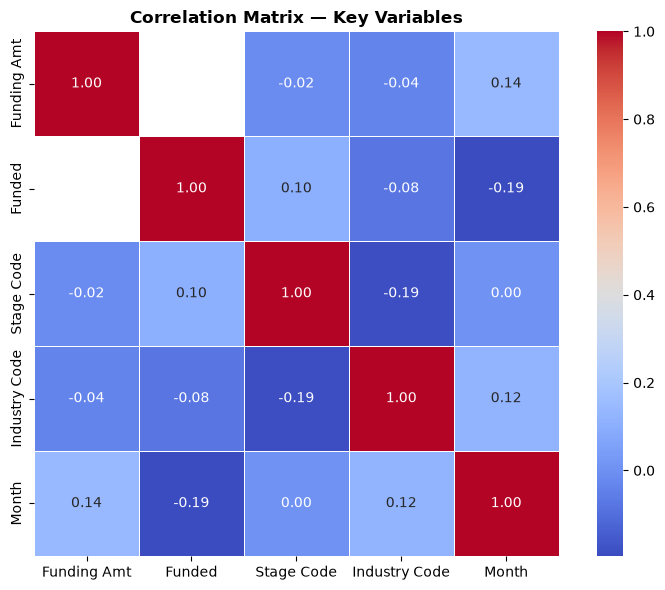

✅ Saved: phase4_correlation_heatmap.png


In [11]:
# Create images folder
os.makedirs(IMG_PATH, exist_ok=True)

# Numerical dataframe
num_df = pd.DataFrame()

num_df['Funding Amount (USD)'] = df['Funding Amount (USD)']
num_df['Funded'] = df['Funded']

num_df['Funding Type Code'] = (
    df['Funding Type']
    .astype('category')
    .cat.codes
)

num_df['Industry Code'] = (
    df['Primary Industry']
    .astype('category')
    .cat.codes
)

num_df['Month Code'] = (
    df['Last Funding Date']
    .dt.month
)

# Correlation matrix
corr_matrix = num_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    xticklabels=[
        'Funding Amt',
        'Funded',
        'Stage Code',
        'Industry Code',
        'Month'
    ],
    yticklabels=[
        'Funding Amt',
        'Funded',
        'Stage Code',
        'Industry Code',
        'Month'
    ]
)

plt.title(
    'Correlation Matrix — Key Variables',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMG_PATH,
        'phase4_correlation_heatmap.png'
    ),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved: phase4_correlation_heatmap.png")

## 🧪 Phase 5: Hypothesis Testing

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

# ==========================
# LOAD DATASET
# ==========================

DATA_PATH = r"C:\Users\ADMIN\OneDrive\Desktop\Startup Funding Success Probability\data\Recently Funded Startups In India 2026.csv"

df = pd.read_csv(DATA_PATH)

# ==========================
# DATA CLEANING
# ==========================

df.drop_duplicates(inplace=True)

df['Funding Amount (USD)'] = (
    df['Funding Amount (USD)']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Funding Amount (USD)'] = pd.to_numeric(
    df['Funding Amount (USD)'],
    errors='coerce'
)

df['Funded'] = df['Funding Amount (USD)'].notna().astype(int)

df['Primary Industry'] = (
    df['Industry']
    .astype(str)
    .str.split(',')
    .str[0]
    .str.strip()
)

df['Last Funding Date'] = pd.to_datetime(
    df['Last Funding Date'],
    errors='coerce'
)

df['Funding Month'] = df['Last Funding Date'].dt.month_name()

# ==========================
# TEST 1 : ANOVA
# ==========================

print('=' * 60)
print('TEST 1: ANOVA — Funding Stage vs Funding Amount')
print('=' * 60)

groups = [
    g['Funding Amount (USD)'].dropna().values
    for _, g in df.groupby('Funding Type')
    if len(g['Funding Amount (USD)'].dropna()) > 1
]

if len(groups) >= 2:

    f_stat, p_val = stats.f_oneway(*groups)

    print(f'F-statistic : {f_stat:.4f}')
    print(f'P-value     : {p_val:.6f}')

    if p_val < 0.05:
        print('✅ Significant Difference Found')
    else:
        print('❌ No Significant Difference')

else:
    print('Not enough groups for ANOVA')

# ==========================
# TEST 2 : CHI-SQUARE
# ==========================

print('\n' + '=' * 60)
print('TEST 2: Industry vs Funding Disclosure')
print('=' * 60)

ct = pd.crosstab(
    df['Primary Industry'],
    df['Funded']
)

if ct.shape[0] > 1 and ct.shape[1] > 1:

    chi2, p_chi, dof, expected = stats.chi2_contingency(ct)

    print(f'Chi-Square : {chi2:.4f}')
    print(f'P-value    : {p_chi:.6f}')
    print(f'DOF        : {dof}')

    if p_chi < 0.05:
        print('✅ Significant Association Found')
    else:
        print('❌ No Significant Association')

else:
    print('Not enough data')

# ==========================
# TEST 3 : T-TEST
# ==========================

print('\n' + '=' * 60)
print('TEST 3: January vs February Funding')
print('=' * 60)

jan = df[
    df['Funding Month'] == 'January'
]['Funding Amount (USD)'].dropna()

feb = df[
    df['Funding Month'] == 'February'
]['Funding Amount (USD)'].dropna()

if len(jan) > 1 and len(feb) > 1:

    t_stat, p_t = stats.ttest_ind(
        jan,
        feb,
        equal_var=False
    )

    print(f'T-statistic : {t_stat:.4f}')
    print(f'P-value     : {p_t:.6f}')
    print(f'January Mean : ${jan.mean():,.0f}')
    print(f'February Mean: ${feb.mean():,.0f}')

    if p_t < 0.05:
        print('✅ Significant Difference Found')
    else:
        print('❌ No Significant Difference')

else:
    print('Not enough January or February data')

TEST 1: ANOVA — Funding Stage vs Funding Amount
F-statistic : 20.4157
P-value     : 0.000000
✅ Significant Difference Found

TEST 2: Industry vs Funding Disclosure
Chi-Square : 68.3522
P-value    : 0.013945
DOF        : 45
✅ Significant Association Found

TEST 3: January vs February Funding
T-statistic : -1.7418
P-value     : 0.085674
January Mean : $7,136,741
February Mean: $19,331,325
❌ No Significant Difference


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23464\722797193.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Last Funding Date'] = pd.to_datetime(


## 🗂️ Phase 6: Startup Segmentation

In [4]:
# Create Funded column if not already present
df['Funding Amount (USD)'] = pd.to_numeric(
    df['Funding Amount (USD)'],
    errors='coerce'
)

df['Funded'] = df['Funding Amount (USD)'].notna().astype(int)

# Startup Segmentation
def segment_startup(row):

    ft = str(row['Funding Type'])

    if ft in ['Series D', 'Series E']:
        return 'High-Growth'

    elif ft == 'Private Equity':
        return 'Revenue-Driven'

    elif ft in ['Series B', 'Series C']:
        return 'Growth Stage'

    elif ft == 'Series A':
        return 'Early Growth'

    elif ft == 'Seed':
        return 'Early Stage'

    elif ft == 'Pre-Seed':
        return 'Very Early / High-Risk'

    else:
        return 'Other'


df['Segment'] = df.apply(segment_startup, axis=1)

seg = (
    df.groupby('Segment')
      .agg(
          Count=('Funding Type', 'count'),
          Funded_Count=('Funded', 'sum'),
          Funded_Rate=('Funded', 'mean'),
          Mean_Funding=('Funding Amount (USD)', 'mean'),
          Median_Funding=('Funding Amount (USD)', 'median')
      )
      .sort_values('Mean_Funding', ascending=False)
)

print('=' * 60)
print('STARTUP SEGMENTS — ANALYSIS')
print('=' * 60)

for idx, row in seg.iterrows():

    print(f"\n{idx}")
    print(f"Total Startups : {int(row['Count'])}")
    print(f"Funded Rate    : {row['Funded_Rate']*100:.1f}%")

    if pd.notna(row['Mean_Funding']):
        print(f"Mean Funding   : ${row['Mean_Funding']:,.0f}")

    if pd.notna(row['Median_Funding']):
        print(f"Median Funding : ${row['Median_Funding']:,.0f}")

STARTUP SEGMENTS — ANALYSIS

Revenue-Driven
Total Startups : 7
Funded Rate    : 71.4%
Mean Funding   : $141,018,296
Median Funding : $115,738,738

High-Growth
Total Startups : 4
Funded Rate    : 100.0%
Mean Funding   : $40,875,734
Median Funding : $36,459,162

Growth Stage
Total Startups : 10
Funded Rate    : 90.0%
Mean Funding   : $16,210,683
Median Funding : $18,000,000

Early Growth
Total Startups : 16
Funded Rate    : 93.8%
Mean Funding   : $11,283,990
Median Funding : $8,823,156

Other
Total Startups : 7
Funded Rate    : 85.7%
Mean Funding   : $7,401,873
Median Funding : $1,845,000

Early Stage
Total Startups : 44
Funded Rate    : 88.6%
Mean Funding   : $2,125,245
Median Funding : $1,985,210

Very Early / High-Risk
Total Startups : 12
Funded Rate    : 75.0%
Mean Funding   : $549,061
Median Funding : $221,366


                Count  Funded_Count  Funded_Rate  Mean_Funding  Median_Funding
Segment                                                                       
Revenue-Driven      7             5     0.714286  1.410183e+08     115738738.0
High-Growth         4             4     1.000000  4.087573e+07      36459162.0
Growth Stage       10             9     0.900000  1.621068e+07      18000000.0
Early Growth       16            15     0.937500  1.128399e+07       8823156.0
Other               7             6     0.857143  7.401873e+06       1845000.0


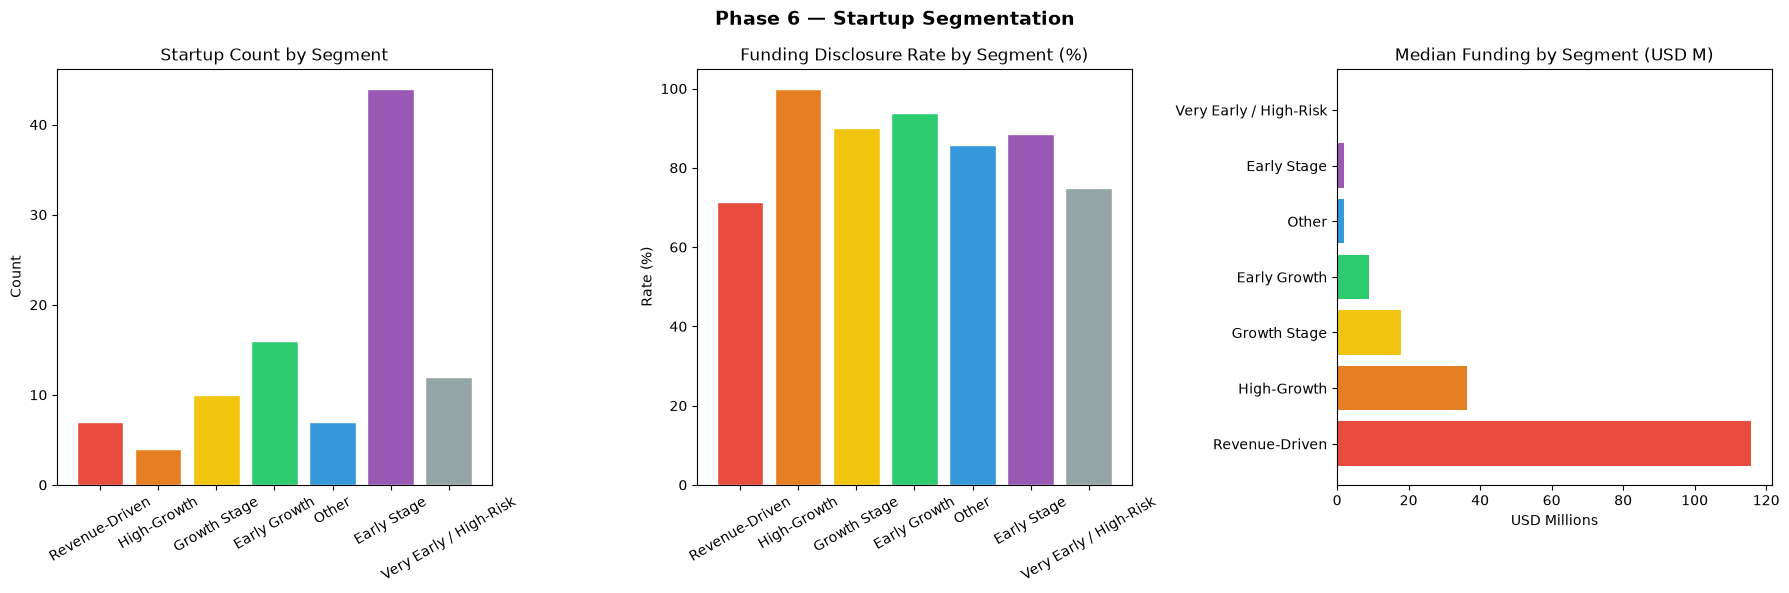

✅ Saved: phase6_segmentation.png


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create images folder
IMG_PATH = "images"
os.makedirs(IMG_PATH, exist_ok=True)

# Check that seg exists
print(seg.head())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 6 — Startup Segmentation',
             fontsize=14,
             fontweight='bold')

seg_order = seg.index.tolist()

colors = [
    '#e74c3c',
    '#e67e22',
    '#f1c40f',
    '#2ecc71',
    '#3498db',
    '#9b59b6',
    '#95a5a6'
]

# Startup Count
axes[0].bar(
    seg_order,
    seg['Count'],
    color=colors[:len(seg_order)],
    edgecolor='white'
)

axes[0].set_title('Startup Count by Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Funding Rate
axes[1].bar(
    seg_order,
    seg['Funded_Rate'] * 100,
    color=colors[:len(seg_order)],
    edgecolor='white'
)

axes[1].set_title('Funding Disclosure Rate by Segment (%)')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

# Median Funding
axes[2].barh(
    seg_order,
    seg['Median_Funding'] / 1_000_000,
    color=colors[:len(seg_order)]
)

axes[2].set_title('Median Funding by Segment (USD M)')
axes[2].set_xlabel('USD Millions')

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMG_PATH,
        'phase6_segmentation.png'
    ),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved: phase6_segmentation.png")

## 💡 Phase 7: Business Insights & Recommendations

In [7]:
# Check that df exists
try:
    df
except NameError:
    print("ERROR: Dataset not loaded. Run the CSV loading cell first.")
else:

    # Create missing columns if needed
    if 'Funded' not in df.columns:
        df['Funding Amount (USD)'] = pd.to_numeric(
            df['Funding Amount (USD)'],
            errors='coerce'
        )
        df['Funded'] = df['Funding Amount (USD)'].notna().astype(int)

    if 'Primary Industry' not in df.columns:
        df['Primary Industry'] = (
            df['Industry']
            .astype(str)
            .str.split(',')
            .str[0]
            .str.strip()
        )

    # Top industries
    top5_ind = (
        df.groupby('Primary Industry')['Funding Amount (USD)']
          .sum()
          .sort_values(ascending=False)
          .head(5)
    )

    # Top funding stage
    top_stage = (
        df.groupby('Funding Type')['Funding Amount (USD)']
          .mean()
          .idxmax()
    )

    # AI funding probability
    ai_prob = (
        df[
            df['Industry']
            .astype(str)
            .str.contains('Artificial Intelligence', case=False, na=False)
        ]['Funded']
        .mean()
    )

    print('=' * 60)
    print('BUSINESS INSIGHTS — FINAL SUMMARY')
    print('=' * 60)

    print('\nQ1. WHAT FACTORS CONTRIBUTE MOST TO FUNDING SUCCESS?')
    print('• Funding Stage is a strong predictor of funding amount')
    print('• Industry sector influences disclosure patterns')
    print('• Private Equity and late-stage rounds attract larger investments')

    print('\nQ2. WHICH INDUSTRIES ATTRACT MORE INVESTMENT?')
    print('Top 5 Industries by Total Funding:')

    for ind, amt in top5_ind.items():
        print(f'• {ind:30s} : ${amt/1e6:.1f}M')

    print('\nQ3. DO LATER-STAGE STARTUPS HAVE AN ADVANTAGE?')
    print('• Yes, later-stage startups generally receive larger investments')
    print(f'• Highest average funding stage: {top_stage}')

    print('\nQ4. WHICH SEGMENTS HAVE HIGH POTENTIAL?')
    print(f'• AI startups funding disclosure rate: {ai_prob*100:.1f}%')
    print('• Growth-stage and Private Equity rounds show strong funding levels')

    print('\nQ5. RECOMMENDATIONS FOR INVESTORS')
    print('• Focus on high-growth sectors')
    print('• Diversify across stages')
    print('• Monitor AI, FinTech, Healthcare, and Energy startups')

    print('=' * 60)

BUSINESS INSIGHTS — FINAL SUMMARY

Q1. WHAT FACTORS CONTRIBUTE MOST TO FUNDING SUCCESS?
• Funding Stage is a strong predictor of funding amount
• Industry sector influences disclosure patterns
• Private Equity and late-stage rounds attract larger investments

Q2. WHICH INDUSTRIES ATTRACT MORE INVESTMENT?
Top 5 Industries by Total Funding:
• Energy                         : $385.2M
• Finance                        : $304.5M
• Agriculture                    : $110.6M
• FinTech                        : $86.3M
• Food and Beverage              : $67.3M

Q3. DO LATER-STAGE STARTUPS HAVE AN ADVANTAGE?
• Yes, later-stage startups generally receive larger investments
• Highest average funding stage: Private Equity

Q4. WHICH SEGMENTS HAVE HIGH POTENTIAL?
• AI startups funding disclosure rate: 100.0%
• Growth-stage and Private Equity rounds show strong funding levels

Q5. RECOMMENDATIONS FOR INVESTORS
• Focus on high-growth sectors
• Diversify across stages
• Monitor AI, FinTech, Healthcare, and

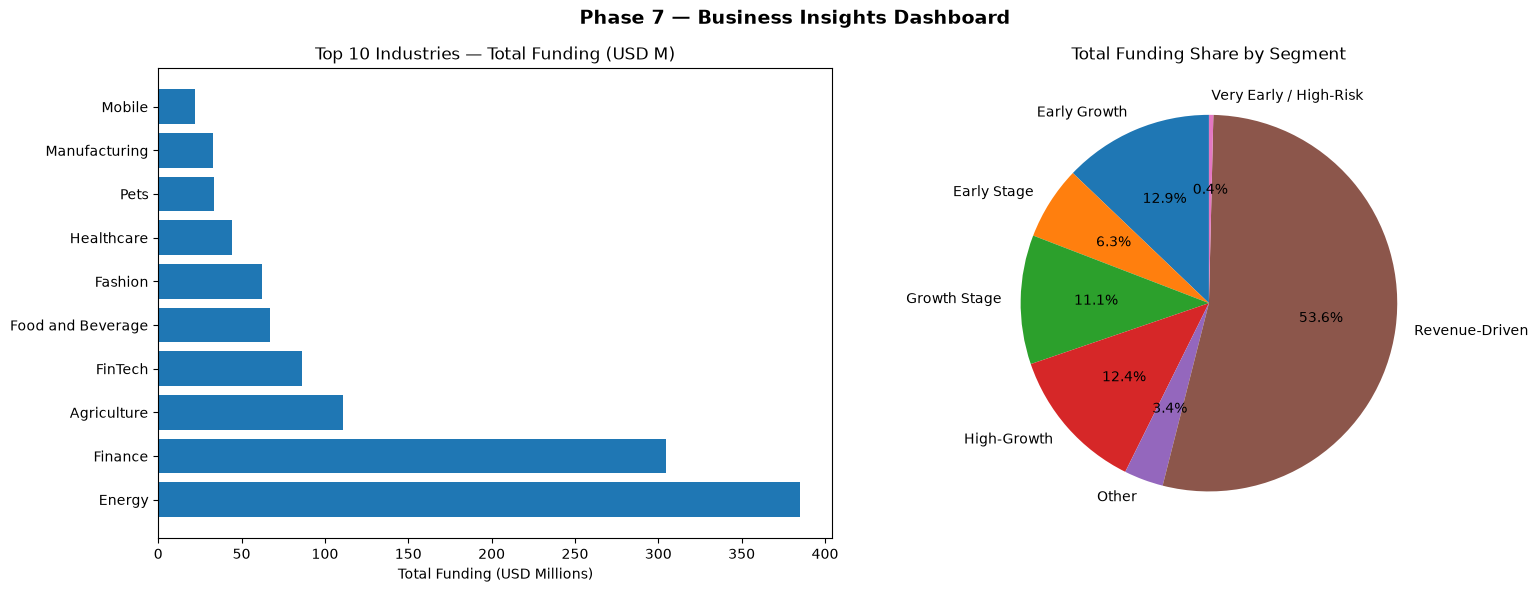

✅ Saved: phase7_business_insights.png
🎉 ALL PHASES COMPLETE!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Check if dataframe exists
try:
    df
except NameError:
    print("ERROR: df is not defined.")
    print("Load the CSV file first using pd.read_csv().")

else:

    # Create image folder
    IMG_PATH = "images"
    os.makedirs(IMG_PATH, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        'Phase 7 — Business Insights Dashboard',
        fontsize=14,
        fontweight='bold'
    )

    # Top Industries
    top10 = (
        df.groupby('Primary Industry')['Funding Amount (USD)']
          .sum()
          .sort_values(ascending=False)
          .head(10)
    )

    axes[0].barh(
        top10.index,
        top10.values / 1_000_000
    )

    axes[0].set_title(
        'Top 10 Industries — Total Funding (USD M)'
    )

    axes[0].set_xlabel(
        'Total Funding (USD Millions)'
    )

    # Segment Pie Chart
    seg_total = (
        df.groupby('Segment')['Funding Amount (USD)']
          .sum()
    )

    axes[1].pie(
        seg_total.values,
        labels=seg_total.index,
        autopct='%1.1f%%',
        startangle=90
    )

    axes[1].set_title(
        'Total Funding Share by Segment'
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            IMG_PATH,
            'phase7_business_insights.png'
        ),
        dpi=150
    )

    plt.show()

    print("✅ Saved: phase7_business_insights.png")
    print("🎉 ALL PHASES COMPLETE!")